In [38]:
# Name: Octavio Morales
# CWID: 20006348
# Assignment: Homework 3- KNN

Import Modules

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Handling Data For Assignment

In [40]:
temp= pd.read_csv('breast-cancer-wisconsin.csv')
temp= temp.drop(columns='Sample')
temp= temp.replace('?', np.nan)
temp= temp.dropna()
temp= temp.astype(float) # Necessary to handling data with numeric types
temp['Class']= temp['Class'].map({2: 0, 4: 1})

Starting and Completing the KNN Methodology

Accuracy for k=35: 0.9463414634146341
Confusion Matrix for k=35: 
[[125   2]
 [  9  69]]
Classification Report for k=35: 
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       127
           1       0.97      0.88      0.93        78

    accuracy                           0.95       205
   macro avg       0.95      0.93      0.94       205
weighted avg       0.95      0.95      0.95       205


Accuracy for k=10: 0.9512195121951219
Confusion Matrix for k=10: 
[[125   2]
 [  8  70]]
Classification Report for k=10: 
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       127
           1       0.97      0.90      0.93        78

    accuracy                           0.95       205
   macro avg       0.96      0.94      0.95       205
weighted avg       0.95      0.95      0.95       205



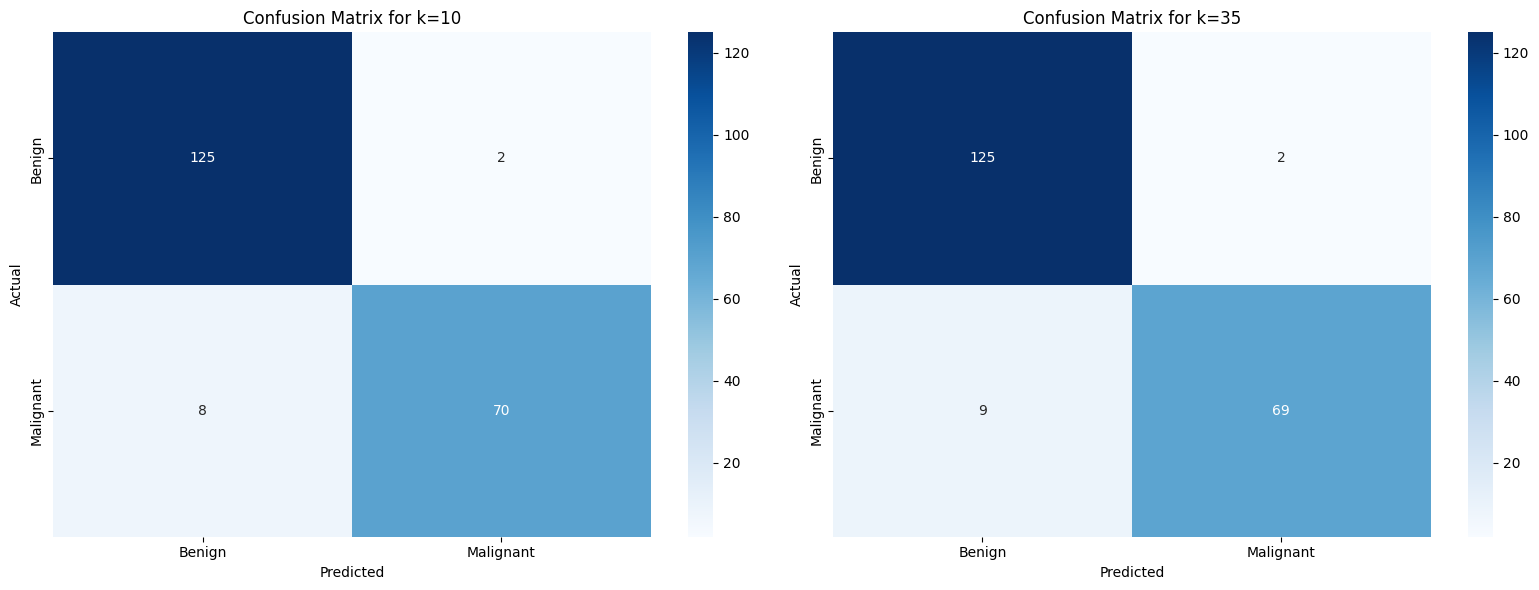

In [41]:
X= temp.drop(columns='Class')
y= temp['Class']
xT, xTest, yT, yTest= train_test_split(X, y, test_size=0.3, random_state=42)

scale= StandardScaler()
xT= scale.fit_transform(xT)
xTest= scale.transform(xTest)

knn35= KNeighborsClassifier(n_neighbors=35)
knn10= KNeighborsClassifier(n_neighbors=10)
knn35.fit(xT, yT)
knn10.fit(xT, yT)
pred35y= knn35.predict(xTest)
pred10y= knn10.predict(xTest)

print(f"Accuracy for k=35: {accuracy_score(yTest, pred35y)}")
print(f"Confusion Matrix for k=35: \n{confusion_matrix(yTest, pred35y)}")
print(f"Classification Report for k=35: \n{classification_report(yTest, pred35y)}")
print()
print(f"Accuracy for k=10: {accuracy_score(yTest, pred10y)}")
print(f"Confusion Matrix for k=10: \n{confusion_matrix(yTest, pred10y)}")
print(f"Classification Report for k=10: \n{classification_report(yTest, pred10y)}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(yTest, pred10y), annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('Confusion Matrix for k=10')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
sns.heatmap(confusion_matrix(yTest, pred35y), annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('Confusion Matrix for k=35')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()